<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/Demo_II_Neural_Networks_in_Action_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Demo II — Neural Networks in Action
### Pretrained Model Demonstrations · Deep Learning Basics Session

---

In this demo you will run **five pretrained models** — one for each architecture covered in Part 2.
All models are loaded from public libraries; no training is required.

| # | Architecture | Task | Library |
|---|---|---|---|
| 1 | **ANN** | Tabular classification (Iris) | TensorFlow / Keras |
| 2 | **CNN** | Image classification | Keras Applications (MobileNetV2) |
| 3 | **RNN** | Sentiment analysis (LSTM) | TensorFlow / Keras |
| 4 | **Transformer** | Sentiment analysis (BERT) | 🤗 Transformers |
| 5 | **Compare** | Transformer vs RNN on same input | Both |

**Libraries used:** `tensorflow`, `keras`, `transformers`, `datasets` (Hugging Face)

---

## ⚙️ Setup — Install & Import Libraries

In [ ]:
# Install required libraries
!pip install tensorflow transformers datasets --quiet
!pip install pillow requests matplotlib numpy scikit-learn --quiet

In [ ]:
# ── Core libraries ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Hugging Face Transformers ────────────────────────────────────────────────
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# ── Data helpers ─────────────────────────────────────────────────────────────
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f'✅  TensorFlow  : {tf.__version__}')
print(f'✅  Keras       : {keras.__version__}')

import transformers
print(f'✅  Transformers: {transformers.__version__}')
print('\nAll libraries loaded successfully!')



✅  TensorFlow  : 2.20.0
✅  Keras       : 3.13.2
✅  Transformers: 5.10.1

All libraries loaded successfully!


---
## 1 · ANN — Tabular Classification with Keras

**Architecture:** Artificial Neural Network (fully-connected layers)  
**Task:** Classify Iris flowers into 3 species using 4 numeric features  
**Dataset:** Iris (built-in to scikit-learn, 150 samples)

> 💡 ANNs shine on **structured / tabular data** where features are already numbers.

In [ ]:
# ── Load the Iris dataset ────────────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target          # 4 features, 3 classes
class_names = iris.target_names        # ['setosa', 'versicolor', 'virginica']
feature_names = iris.feature_names

print('Dataset shape :', X.shape)
print('Classes       :', class_names)


Dataset shape : (150, 4)
Classes       : ['setosa' 'versicolor' 'virginica']


In [ ]:
import pandas as pd

df = pd.DataFrame(data=X, columns=feature_names)
df['species'] = y

print('\nIris Dataset as DataFrame:')
display(df.head())


Iris Dataset as DataFrame:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:


# ── Preprocess: normalise features ──────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode labels for categorical_crossentropy
y_onehot = tf.keras.utils.to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42
)
print(f'\nTrain: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')


Train: 120 samples  |  Test: 30 samples


In [ ]:
# ── Build the ANN with Keras Sequential API ──────────────────────────────────
tf.random.set_seed(42)

model_ann = keras.Sequential([
    # Input layer (implicit) + first hidden layer
    layers.Dense(16, activation='relu', input_shape=(4,), name='hidden_1'),
    layers.Dense(8,  activation='relu',                   name='hidden_2'),
    # Output layer: 3 neurons, one per class
    layers.Dense(3,  activation='softmax',                name='output'),
], name='ANN_Iris')

model_ann.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_ann.summary()

Model: "ANN_Iris"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

Test accuracy : 83.33%


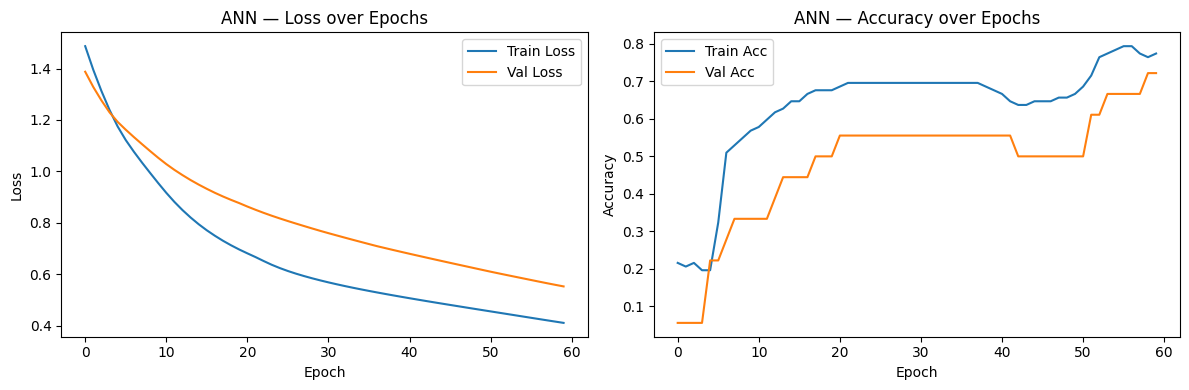

In [ ]:
# ── Train the ANN ────────────────────────────────────────────────────────────
history_ann = model_ann.fit(
    X_train, y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.15,
    verbose=0   # silent — we will plot below
)

# Evaluate on test set
loss, acc = model_ann.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy : {acc:.2%}')

# ── Plot training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_ann.history['loss'],     label='Train Loss')
axes[0].plot(history_ann.history['val_loss'], label='Val Loss')
axes[0].set_title('ANN — Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_ann.history['accuracy'],     label='Train Acc')
axes[1].plot(history_ann.history['val_accuracy'], label='Val Acc')
axes[1].set_title('ANN — Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Make predictions on a few test samples ───────────────────────────────────
sample_indices = [0, 5, 10, 15, 25]
X_sample = X_test[sample_indices]
y_sample = y_test[sample_indices]

probs   = model_ann.predict(X_sample, verbose=0)
preds   = np.argmax(probs, axis=1)
actuals = np.argmax(y_sample, axis=1)

print('Sample Predictions\n' + '-'*50)
for i, (pred, actual, prob) in enumerate(zip(preds, actuals, probs)):
    status = '✅' if pred == actual else '❌'
    print(f'{status}  Predicted: {class_names[pred]:12s}  '
          f'Actual: {class_names[actual]:12s}  '
          f'Confidence: {prob[pred]:.0%}')

print(f'\n📌 Key point: The ANN learned to separate 3 flower species '
      f'from just 4 numeric measurements.')

Sample Predictions
--------------------------------------------------
✅  Predicted: versicolor    Actual: versicolor    Confidence: 56%
✅  Predicted: setosa        Actual: setosa        Confidence: 99%
✅  Predicted: virginica     Actual: virginica     Confidence: 53%
❌  Predicted: virginica     Actual: versicolor    Confidence: 51%
✅  Predicted: virginica     Actual: virginica     Confidence: 53%

📌 Key point: The ANN learned to separate 3 flower species from just 4 numeric measurements.


---
## 2 · CNN — Image Classification with MobileNetV2

**Architecture:** Convolutional Neural Network  
**Model:** MobileNetV2 pretrained on ImageNet (1,000 classes)  
**Task:** Classify any image — we will test with a few public domain photos

> 💡 CNNs use **convolutional filters** to detect edges → shapes → objects. MobileNetV2 was trained on 1.4 million images and can recognise 1,000 different object categories.

In [ ]:
# ── Load MobileNetV2 pretrained on ImageNet ──────────────────────────────────
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input, decode_predictions
)
from tensorflow.keras.preprocessing import image as keras_image
import requests
from PIL import Image
from io import BytesIO

# Download weights the first time (~14 MB)
cnn_model = MobileNetV2(weights='imagenet', include_top=True)
print(f'MobileNetV2 loaded — {cnn_model.count_params():,} parameters')
print('Input shape :', cnn_model.input_shape)
print('Output shape:', cnn_model.output_shape, '(1000 ImageNet classes)')

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded — 3,538,984 parameters
Input shape : (None, 224, 224, 3)
Output shape: (None, 1000) (1000 ImageNet classes)


In [ ]:
# ── Helper: load an image from URL and run inference ─────────────────────────
def classify_image(url, title=''):
    """Download an image, preprocess it, and return the top-3 predictions."""
    response = requests.get(url, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize((224, 224))

    # Convert to array and preprocess (MobileNetV2 expects [-1, 1] range)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension
    img_array = preprocess_input(img_array)

    # Predict
    preds = cnn_model.predict(img_array, verbose=0)
    top3  = decode_predictions(preds, top=3)[0]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title(title or 'Input Image')
    axes[0].axis('off')

    labels = [f'{label} ({score:.0%})' for _, label, score in top3]
    scores = [score for _, _, score in top3]
    axes[1].barh(labels[::-1], scores[::-1], color=['#1A3A5C', '#2E75B6', '#9DC3E6'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Predictions')

    plt.tight_layout()
    plt.show()
    return top3

print('Helper function defined ✅')

Helper function defined ✅


In [ ]:
# ── Test image 1: a cat ──────────────────────────────────────────────────────
# Public domain image from Wikimedia Commons

# TEMPORARY FIX: Redefine classify_image locally with User-Agent header
# The permanent fix should be applied to the classify_image function in the cnn-helper cell.
def classify_image(url, title=''):
    """Download an image, preprocess it, and return the top-3 predictions."""
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    response = requests.get(url, headers=headers, timeout=10)
    img = Image.open(BytesIO(response.content)).convert('RGB')
    img_resized = img.resize((224, 224))

    # Convert to array and preprocess (MobileNetV2 expects [-1, 1] range)
    img_array = keras_image.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension
    img_array = preprocess_input(img_array)

    # Predict
    preds = cnn_model.predict(img_array, verbose=0)
    top3  = decode_predictions(preds, top=3)[0]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img_resized)
    axes[0].set_title(title or 'Input Image')
    axes[0].axis('off')

    labels = [f'{label} ({score:.0%})' for _, label, score in top3]
    scores = [score for _, _, score in top3]
    axes[1].barh(labels[::-1], scores[::-1], color=['#1A3A5C', '#2E75B6', '#9DC3E6'])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Top-3 Predictions')

    plt.tight_layout()
    plt.show()
    return top3

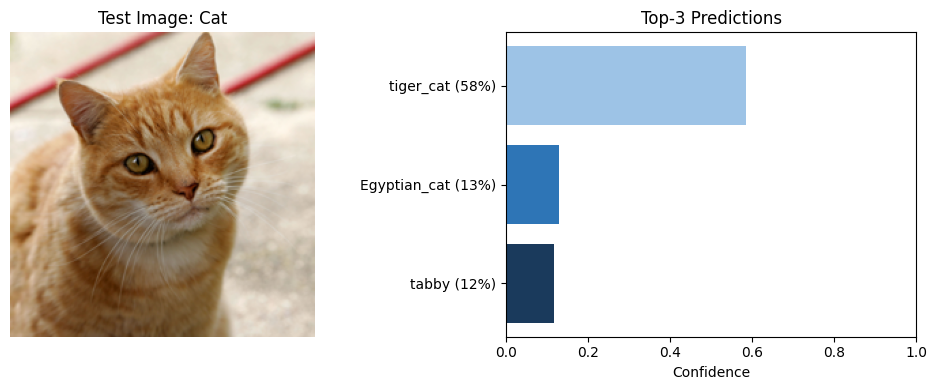


Top-3 predictions:
  1. tiger_cat                 58.44%
  2. Egyptian_cat              12.93%
  3. tabby                     11.57%


In [ ]:
cat_url = "https://upload.wikimedia.org/wikipedia/commons/3/3a/Cat03.jpg"
top3 = classify_image(cat_url, title='Test Image: Cat')

print('\nTop-3 predictions:')
for rank, (_, label, score) in enumerate(top3, 1):
    print(f'  {rank}. {label:<25} {score:.2%}')

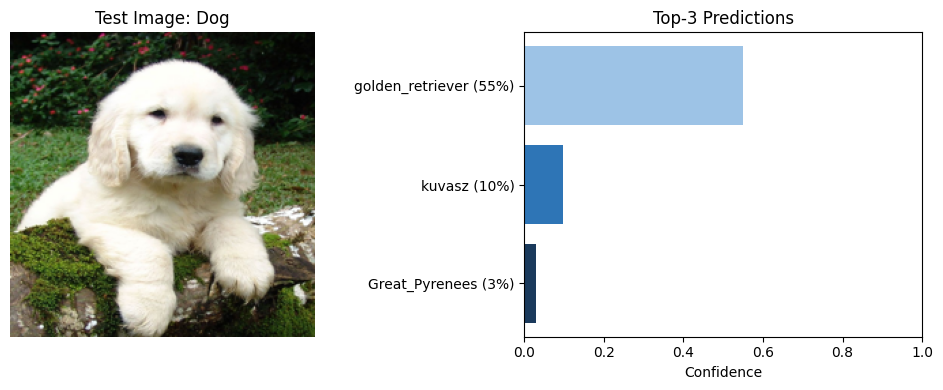


Top-3 predictions:
  1. golden_retriever          55.10%
  2. kuvasz                    9.71%
  3. Great_Pyrenees            2.93%

📌 Key point: The CNN learned visual features (edges → shapes → objects) from 1.4M training images.
   We are simply reusing those learned filters — no training needed!


In [ ]:
# ── Test image 2: a dog ──────────────────────────────────────────────────────
dog_url = "https://upload.wikimedia.org/wikipedia/commons/6/6e/Golde33443.jpg"
top3 = classify_image(dog_url, title='Test Image: Dog')

print('\nTop-3 predictions:')
for rank, (_, label, score) in enumerate(top3, 1):
    print(f'  {rank}. {label:<25} {score:.2%}')

print('\n📌 Key point: The CNN learned visual features (edges → shapes → objects) '
      'from 1.4M training images.\n   We are simply reusing those learned filters — '
      'no training needed!')

In [ ]:
# ── 🔬 Explore: try your own image ───────────────────────────────────────────
# Replace the URL below with any public image URL you like
your_url = 'Try other URLs'

# Uncomment to classify your own image:
# classify_image(your_url, title='My Image')

print('Change the URL above and remove the # to try your own image!')

---
## 3 · RNN/LSTM — Sentiment Analysis with Keras

**Architecture:** Long Short-Term Memory (LSTM) — a type of RNN  
**Task:** Predict whether a movie review is positive or negative  
**Dataset:** IMDB (built-in to Keras — 25,000 labelled reviews)

> 💡 LSTMs process text **word by word**, maintaining a hidden state that carries context across the sequence. They were the dominant architecture for NLP before Transformers.

In [ ]:
# ── Load the IMDB dataset (top 10,000 vocabulary) ────────────────────────────
VOCAB_SIZE   = 10_000   # keep the 10k most frequent words
MAX_LEN      = 200      # pad/truncate reviews to 200 tokens

(X_train_imdb, y_train_imdb), (X_test_imdb, y_test_imdb) = (
    keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
)

print(f'Training reviews : {len(X_train_imdb):,}')
print(f'Test reviews     : {len(X_test_imdb):,}')
print(f'Labels           : 0 = Negative, 1 = Positive')
print(f'\nSample review (encoded): {X_train_imdb[0][:15]} ...')
print(f'Label: {"Positive" if y_train_imdb[0] == 1 else "Negative"}')

# Pad sequences to the same length
X_train_pad = keras.preprocessing.sequence.pad_sequences(
    X_train_imdb, maxlen=MAX_LEN, padding='post', truncating='post'
)
X_test_pad = keras.preprocessing.sequence.pad_sequences(
    X_test_imdb, maxlen=MAX_LEN, padding='post', truncating='post'
)
print(f'\nPadded shape: {X_train_pad.shape}')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews : 25,000
Test reviews     : 25,000
Labels           : 0 = Negative, 1 = Positive

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4] ...
Label: Positive

Padded shape: (25000, 200)


### Sample Input and Output Records for LSTM

In [ ]:
print('--- Input (X_train_imdb) ---')
print(f'Shape of raw training input: {X_train_imdb.shape}')
print('First 3 raw training reviews (encoded):')
for i in range(3):
    print(f'Review {i}: {X_train_imdb[i][:20]}...') # Display first 20 tokens

print('\n--- Output (y_train_imdb) ---')
print(f'Shape of raw training labels: {y_train_imdb.shape}')
print('First 5 raw training labels:')
print(y_train_imdb[:5])

print('\n--- Padded Input (X_train_pad) ---')
print(f'Shape of padded training input: {X_train_pad.shape}')
print('First 3 padded training reviews (first 20 tokens and last 5 tokens):')
for i in range(3):
    print(f'Review {i} (start): {X_train_pad[i][:20]}...')
    print(f'Review {i} (end): {X_train_pad[i][-5:]}')

--- Input (X_train_imdb) ---
Shape of raw training input: (25000,)
First 3 raw training reviews (encoded):
Review 0: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]...
Review 1: [1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14]...
Review 2: [1, 14, 47, 8, 30, 31, 7, 4, 249, 108, 7, 4, 5974, 54, 61, 369, 13, 71, 149, 14]...

--- Output (y_train_imdb) ---
Shape of raw training labels: (25000,)
First 5 raw training labels:
[1 0 0 1 0]

--- Padded Input (X_train_pad) ---
Shape of padded training input: (25000, 200)
First 3 padded training reviews (first 20 tokens and last 5 tokens):
Review 0 (start): [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]...
Review 0 (end): [104   4 226  65  16]
Review 1 (start): [   1  194 1153  194 8255   78  228    5    6 1463 4369 5012  134   26
    4  715    8  118 1634   14]...
Review 1 (end): [0 0 0 0 0]
Review 2 (sta

In [ ]:
# ── Helper to decode an integer-encoded review back to text ──────────────────
word_index   = keras.datasets.imdb.get_word_index()
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(encoded):
    return ' '.join(index_to_word.get(i, '?') for i in encoded if i > 0)

sample_text = decode_review(X_train_imdb[0][:60])
print('Decoded sample (first 60 tokens):')
print(sample_text)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Decoded sample (first 60 tokens):
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film


In [ ]:
# ── Build the LSTM model ─────────────────────────────────────────────────────
tf.random.set_seed(42)

model_lstm = keras.Sequential([
    # Embedding: maps integer word IDs → dense 64-dim vectors
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64,
                     input_length=MAX_LEN, name='embedding'),

    # LSTM: processes the sequence and outputs a single context vector
    layers.LSTM(64, name='lstm'),

    layers.Dropout(0.3, name='dropout'),

    # Output: single neuron, sigmoid → probability of positive sentiment
    layers.Dense(1, activation='sigmoid', name='output'),
], name='LSTM_Sentiment')

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "LSTM_Sentiment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train on a subset for speed (full training takes ~10 min on CPU) ──────────
# Use 5,000 samples for a quick demo; increase for better accuracy
N_TRAIN = 5_000
N_TEST  = 1_000

history_lstm = model_lstm.fit(
    X_train_pad[:N_TRAIN], y_train_imdb[:N_TRAIN],
    epochs=5,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

loss, acc = model_lstm.evaluate(
    X_test_pad[:N_TEST], y_test_imdb[:N_TEST], verbose=0
)
print(f'\nTest accuracy : {acc:.2%}  (trained on {N_TRAIN} samples only)')

Epoch 1/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - accuracy: 0.5066 - loss: 0.6932 - val_accuracy: 0.5227 - val_loss: 0.6927
Epoch 2/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.5621 - loss: 0.6851 - val_accuracy: 0.5307 - val_loss: 0.6928
Epoch 3/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 184ms/step - accuracy: 0.6351 - loss: 0.6310 - val_accuracy: 0.5187 - val_loss: 0.7746
Epoch 4/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.6795 - loss: 0.5426 - val_accuracy: 0.5813 - val_loss: 0.7430
Epoch 5/5
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - accuracy: 0.7092 - loss: 0.4635 - val_accuracy: 0.5787 - val_loss: 0.8429

Test accuracy : 55.20%  (trained on 5000 samples only)


In [ ]:
# ── Predict on new custom reviews ────────────────────────────────────────────
sample_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat.",
    "Terrible film. Boring plot, bad acting, and a complete waste of time.",
    "It was okay. Some parts were good but overall nothing special.",
    "One of the best movies I have ever seen. Highly recommend it to everyone!",
]

def preprocess_custom_review(text):
    """Encode a raw text review as a padded integer sequence."""
    tokens = text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in tokens]  # 2 = UNK
    encoded = [min(i, VOCAB_SIZE - 1) for i in encoded]   # clip to vocab size
    padded = keras.preprocessing.sequence.pad_sequences(
        [encoded], maxlen=MAX_LEN, padding='post', truncating='post'
    )
    return padded

print('LSTM Sentiment Predictions\n' + '-'*55)
for review in sample_reviews:
    x = preprocess_custom_review(review)
    prob = model_lstm.predict(x, verbose=0)[0][0]
    label = '😊 Positive' if prob > 0.5 else '😞 Negative'
    print(f'{label}  ({prob:.0%} positive)  |  "{review[:55]}..."')

print(f'\n📌 Key point: The LSTM read the review token-by-token, '
      f'carrying a memory of earlier words to make its prediction.')

LSTM Sentiment Predictions
-------------------------------------------------------
😊 Positive  (59% positive)  |  "This movie was absolutely fantastic! The acting was sup..."
😊 Positive  (59% positive)  |  "Terrible film. Boring plot, bad acting, and a complete ..."
😊 Positive  (59% positive)  |  "It was okay. Some parts were good but overall nothing s..."
😊 Positive  (59% positive)  |  "One of the best movies I have ever seen. Highly recomme..."

📌 Key point: The LSTM read the review token-by-token, carrying a memory of earlier words to make its prediction.


---
## 4 · Transformer — Sentiment Analysis with BERT

**Architecture:** Transformer (encoder-only, BERT-style)  
**Model:** `distilbert-base-uncased-finetuned-sst-2-english`  
**Task:** Sentiment analysis — same task as the LSTM above

> 💡 BERT processes **the entire sentence in parallel** using Self-Attention, allowing every word to directly attend to every other word. This is why Transformers capture long-range relationships so much better than RNNs.

In [ ]:
# ── Load a pretrained Transformer pipeline ────────────────────────────────────
# distilbert is a smaller, faster version of BERT (40% fewer params, 97% of BERT accuracy)
print('Loading DistilBERT sentiment pipeline (first run downloads ~260 MB)...')

sentiment_pipeline = pipeline(
    task='sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
)

print('\n✅ Transformer pipeline ready!')
print('Model: DistilBERT fine-tuned on SST-2 (Stanford Sentiment Treebank)')

Loading DistilBERT sentiment pipeline (first run downloads ~260 MB)...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]


✅ Transformer pipeline ready!
Model: DistilBERT fine-tuned on SST-2 (Stanford Sentiment Treebank)


In [ ]:
# ── Quick test on a single sentence ──────────────────────────────────────────
test_sentence = "Deep learning is an incredibly powerful technique for solving real-world problems."

result = sentiment_pipeline(test_sentence)
print(f'Input  : "{test_sentence}"')
print(f'Output : {result[0]}')

Input  : "Deep learning is an incredibly powerful technique for solving real-world problems."
Output : {'label': 'POSITIVE', 'score': 0.9998623132705688}


In [ ]:
# ── Run the Transformer on the same reviews used for the LSTM ─────────────────
results_transformer = sentiment_pipeline(sample_reviews)

print('Transformer (BERT) Sentiment Predictions\n' + '-'*55)
for review, result in zip(sample_reviews, results_transformer):
    label = result['label']
    score = result['score']
    emoji = '😊' if label == 'POSITIVE' else '😞'
    print(f'{emoji} {label:8s}  ({score:.0%})  |  "{review[:55]}..."')

print(f'\n📌 Key point: BERT saw the whole sentence at once using Self-Attention — '
      f'no sequential processing needed.')

Transformer (BERT) Sentiment Predictions
-------------------------------------------------------
😊 POSITIVE  (100%)  |  "This movie was absolutely fantastic! The acting was sup..."
😞 NEGATIVE  (100%)  |  "Terrible film. Boring plot, bad acting, and a complete ..."
😞 NEGATIVE  (99%)  |  "It was okay. Some parts were good but overall nothing s..."
😊 POSITIVE  (100%)  |  "One of the best movies I have ever seen. Highly recomme..."

📌 Key point: BERT saw the whole sentence at once using Self-Attention — no sequential processing needed.


---
## 5 · Side-by-Side Comparison — LSTM vs Transformer

Let's test both models on the **same set of reviews** and compare their predictions and confidence levels.

| Feature | LSTM (RNN) | Transformer (BERT) |
|---|---|---|
| Processes text | Sequentially (token by token) | In parallel (all tokens at once) |
| Long-range context | Limited by memory fading | Strong (direct attention to any token) |
| Pretraining data | ~5,000 reviews (our demo) | 800M+ words (Wikipedia + BookCorpus) |
| Parameters | ~650K (our demo model) | ~66M (DistilBERT) |

In [ ]:
# ── Test reviews designed to challenge both models ─────────────────────────
comparison_reviews = [
    # Clear cases
    "I loved every minute of this film. A true masterpiece.",
    "Dull, predictable, and poorly acted. Save your time.",
    # Tricky cases — negation, sarcasm
    "Not bad at all, actually quite enjoyable.",
    "Oh great, another two hours of my life I will never get back.",
    # Long-range dependency
    "Although the first hour was slow and the characters were underdeveloped, "
    "the breathtaking finale and outstanding cinematography made it absolutely worth watching.",
]

print('Prepared comparison reviews ✅')
for i, r in enumerate(comparison_reviews, 1):
    print(f'  {i}. {r[:70]}...' if len(r) > 70 else f'  {i}. {r}')

Prepared comparison reviews ✅
  1. I loved every minute of this film. A true masterpiece.
  2. Dull, predictable, and poorly acted. Save your time.
  3. Not bad at all, actually quite enjoyable.
  4. Oh great, another two hours of my life I will never get back.
  5. Although the first hour was slow and the characters were underdevelope...


In [ ]:
# ── Run both models ───────────────────────────────────────────────────────────

# LSTM predictions
lstm_results = []
for review in comparison_reviews:
    x    = preprocess_custom_review(review)
    prob = model_lstm.predict(x, verbose=0)[0][0]
    lstm_results.append(('POSITIVE' if prob > 0.5 else 'NEGATIVE', prob if prob > 0.5 else 1 - prob))

# Transformer predictions
bert_results = sentiment_pipeline(comparison_reviews)

# ── Print results side by side ────────────────────────────────────────────────
print(f'{"Review":<52}  {"LSTM":^18}  {"BERT":^18}')
print('-' * 92)
for review, lstm, bert in zip(comparison_reviews, lstm_results, bert_results):
    short = (review[:48] + '...') if len(review) > 48 else review
    lstm_str = f"{lstm[0]:8s} ({lstm[1]:.0%})"
    bert_str = f"{bert['label']:8s} ({bert['score']:.0%})"
    print(f'{short:<52}  {lstm_str:^18}  {bert_str:^18}')

Review                                                       LSTM                BERT       
--------------------------------------------------------------------------------------------
I loved every minute of this film. A true master...     POSITIVE (59%)     POSITIVE (100%)  
Dull, predictable, and poorly acted. Save your t...     POSITIVE (59%)     NEGATIVE (100%)  
Not bad at all, actually quite enjoyable.               POSITIVE (59%)     POSITIVE (100%)  
Oh great, another two hours of my life I will ne...     POSITIVE (59%)      POSITIVE (82%)  
Although the first hour was slow and the charact...     POSITIVE (59%)     POSITIVE (100%)  


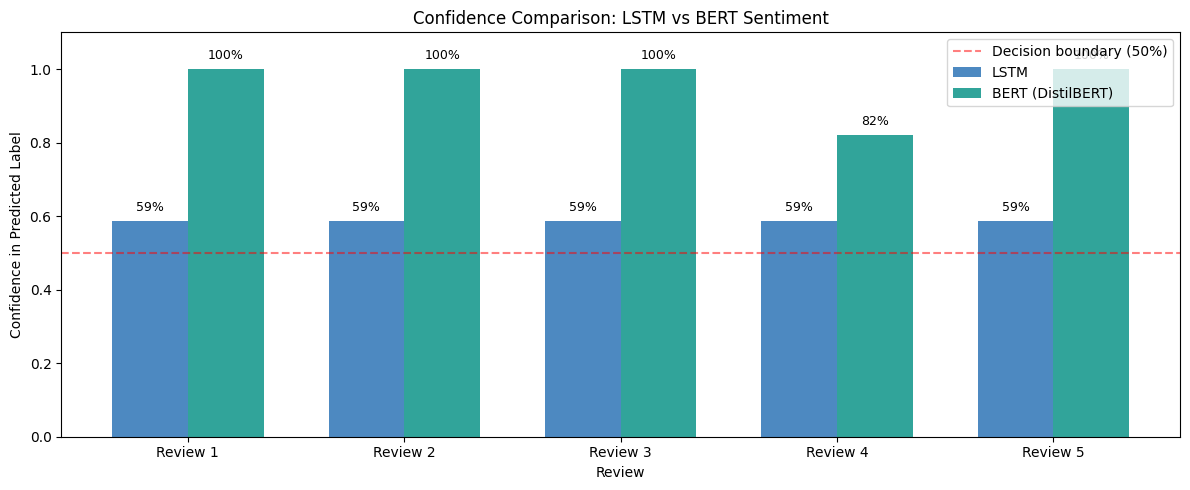

Review descriptions:
  Review 1: I loved every minute of this film. A true masterpiece.
  Review 2: Dull, predictable, and poorly acted. Save your time.
  Review 3: Not bad at all, actually quite enjoyable.
  Review 4: Oh great, another two hours of my life I will never get back.
  Review 5: Although the first hour was slow and the characters were underdeveloped, th...


In [ ]:
# ── Visualise confidence comparison ──────────────────────────────────────────
labels_short = [f'Review {i+1}' for i in range(len(comparison_reviews))]

lstm_confidences = [r[1] for r in lstm_results]
bert_confidences = [r['score'] for r in bert_results]

x = np.arange(len(labels_short))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, lstm_confidences, width, label='LSTM',        color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + width/2, bert_confidences, width, label='BERT (DistilBERT)', color='#0D9488', alpha=0.85)

ax.set_xlabel('Review')
ax.set_ylabel('Confidence in Predicted Label')
ax.set_title('Confidence Comparison: LSTM vs BERT Sentiment')
ax.set_xticks(x)
ax.set_xticklabels(labels_short)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary (50%)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('Review descriptions:')
for i, r in enumerate(comparison_reviews, 1):
    print(f'  Review {i}: {r[:75]}...' if len(r) > 75 else f'  Review {i}: {r}')

---

# 6 · 🚀 Real-World Applications of Transformers

In this section, we explore two powerful applications of Transformer models using the Hugging Face `pipeline` API:

1. **Named Entity Recognition (NER)** – Extract people, organizations, locations, and other entities from text.
2. **Fill-Mask** – Observe how BERT predicts missing words using its pre-training objective.

These examples demonstrate how pre-trained Transformer models can be applied directly to real-world NLP tasks with just a few lines of code.

---

## 6.1 👤 Named Entity Recognition (NER)

### What is NER?

Named Entity Recognition (NER) identifies and classifies important entities within text into predefined categories such as:

| Entity Type | Description | Example |
|-------------|-------------|---------|
| **PER** | Person | Sundar Pichai |
| **ORG** | Organization | Google |
| **LOC** | Location | California |
| **MISC** | Miscellaneous | FIFA World Cup |

### Model Used

**Model:** `dslim/bert-base-NER`

This BERT-based model has been fine-tuned on the CoNLL-2003 NER dataset and can identify entities in natural language text.

### Learning Objectives

After completing this example, you will be able to:

- Extract entities from text automatically.
- Understand how BERT performs token-level classification.
- Use the Hugging Face `pipeline()` API for NER tasks.
- Interpret confidence scores associated with predictions.

### Example

The following code processes several sentences and identifies people, organizations, and locations mentioned in the text.

---


In [ ]:
# ══════════════════════════════════════════════════
# Named Entity Recognition (NER)
# Model: dslim/bert-base-NER
# Finds: PER (people), ORG (organizations), LOC (locations), MISC
# ══════════════════════════════════════════════════
ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"   # merge sub-word tokens
)

texts = [
    "Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.",
    "The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.",
    "Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.",
]

entity_icons = {"PER": "👤", "ORG": "🏢", "LOC": "📍", "MISC": "🔖"}

for text in texts:
    entities = ner(text)
    print(f"\n📝 {text}")
    print(f"  {'Type':6s}  {'Entity':25s}  Confidence")
    print(f"  {'─'*6}  {'─'*25}  {'─'*10}")
    for e in entities:
        icon = entity_icons.get(e['entity_group'], '🔖')
        print(f"  {icon} {e['entity_group']:4s}  {e['word']:25s}  {e['score']:.2%}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📝 Sundar Pichai is the CEO of Google, which is headquartered in Mountain View, California.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  👤 PER   Sundar Pichai              99.19%
  🏢 ORG   Google                     99.89%
  📍 LOC   Mountain View              99.77%
  📍 LOC   California                 99.92%

📝 The FIFA World Cup 2026 will be held in the United States, Canada, and Mexico.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🔖 MISC  FIFA World Cup 2026        91.35%
  📍 LOC   United States              99.95%
  📍 LOC   Canada                     99.98%
  📍 LOC   Mexico                     99.98%

📝 Elon Musk founded SpaceX in 2002 and acquired Twitter, renaming it to X.
  Type    Entity                     Confidence
  ──────  ─────────────────────────  ──────────
  🏢 ORG   Elon                       88.68%
  👤 PER   Mu                         56.98%
  🏢 ORG   ##sk        

## 6.2 🎭 Fill-Mask: BERT's Pre-training Task

### What is Fill-Mask?

One of BERT's original training objectives is the **Masked Language Modeling (MLM)** task.

During training:

- Random words are replaced with the special token `[MASK]`.
- BERT learns to predict the missing word using the surrounding context.

Example:

```text
The capital of India is [MASK].

In [ ]:
# ══════════════════════════════════════════════════
# Fill-Mask (BERT's Pre-training Task)
# See what BERT predicts in missing positions
# ══════════════════════════════════════════════════
fill_mask = pipeline("fill-mask", model="bert-base-uncased")

masked_sentences = [
    "The capital of India is [MASK].",
    "Python is a high-level [MASK] language.",
    "The [MASK] is the powerhouse of the cell.",
    "Albert Einstein developed the theory of [MASK].",
]

print("🎭 BERT's Fill-in-the-Blank Predictions:")
print("(showing top 4 predictions per sentence)\n")

for sentence in masked_sentences:
    predictions = fill_mask(sentence, top_k=4)
    print(f"❓ '{sentence}'")
    for pred in predictions:
        bar  = "█" * int(pred['score'] * 35)
        word = pred['token_str'].strip()
        print(f"   {word:20s} {pred['score']:.2%}  {bar}")
    print()

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🎭 BERT's Fill-in-the-Blank Predictions:
(showing top 4 predictions per sentence)

❓ 'The capital of India is [MASK].'
   mumbai               17.68%  ██████
   delhi                15.31%  █████
   pune                 13.92%  ████
   hyderabad            6.50%  ██

❓ 'Python is a high-level [MASK] language.'
   programming          94.37%  █████████████████████████████████
   python               0.69%  
   assembly             0.53%  
   natural              0.44%  

❓ 'The [MASK] is the powerhouse of the cell.'
   female               1.93%  
   woman                1.43%  
   speaker              1.10%  
   mother               1.02%  

❓ 'Albert Einstein developed the theory of [MASK].'
   relativity           94.19%  ████████████████████████████████
   gravity              0.91%  
   motion               0.43%  
   light                0.40%  



---
## ✏️ Exercises

Try these on your own to deepen your understanding.

**Exercise 1 — ANN**  
Change the ANN architecture: add a third hidden layer with 32 neurons. Does accuracy improve?

**Exercise 2 — CNN**  
Find a URL of any image (food, animal, vehicle) and run it through MobileNetV2. How confident is the model?

**Exercise 3 — LSTM**  
Write your own movie review (2–3 sentences). Preprocess it and run it through the LSTM. Was the prediction correct?

**Exercise 4 — Transformer**  
Run the BERT pipeline on a sarcastic sentence like `"Oh wow, this was just *SO* entertaining..."`. Does it handle sarcasm?

**Exercise 5 — Compare**  
Write a long review (5–6 sentences) where the overall sentiment only becomes clear at the very end.  
Which model gets it right — the LSTM or BERT? Why?

---

## 📋 Summary

| Architecture | What you ran | Key insight |
|---|---|---|
| **ANN** | Iris classification | Learns numeric patterns layer by layer |
| **CNN** | Image classification (MobileNetV2) | Reusable visual features — no retraining needed |
| **LSTM** | Sentiment analysis (IMDB) | Processes text token-by-token, memory fades over distance |
| **Transformer** | Sentiment analysis (DistilBERT) | Attends to all tokens in parallel — strong long-range context |
| **Comparison** | LSTM vs BERT on tricky reviews | BERT is more confident and handles negation/long context better |

### 🚀 Next Steps
- **Transformers session** — explore encoder-only (BERT), decoder-only (GPT), and encoder-decoder (T5) architectures with Hugging Face
- **Fine-tuning** — adapt a pretrained model to your own dataset in a few lines of Keras
- **Practice** — try Kaggle's NLP Getting Started competition using a Transformer pipeline

---
*Deep Learning Basics Session · Demo II*